In [9]:
!pip install lifelines

In [10]:
import pandas as pd

In [11]:
# Import the dataset
dataset = pd.read_csv("data/lung.csv")
dataset.head()

,inst,time,status,age,sex,ph.ecog,ph.karno,pat.karno,meal.cal,wt.loss
0,3.0,306,2,74,1,1.0,90.0,100.0,1175.0,NaN
1,3.0,455,2,68,1,0.0,90.0,90.0,1225.0,15.0
2,3.0,1010,1,56,1,0.0,90.0,90.0,NaN,15.0
3,5.0,210,2,57,1,1.0,90.0,60.0,1150.0,11.0
4,1.0,883,2,60,1,0.0,100.0,90.0,NaN,0.0


In [12]:
# Data organization
dataset.loc[dataset.status == 1, "status"] = 0
dataset.loc[dataset.status == 2, "status"] = 1
dataset.head()

,inst,time,status,age,sex,ph.ecog,ph.karno,pat.karno,meal.cal,wt.loss
0,3.0,306,1,74,1,1.0,90.0,100.0,1175.0,NaN
1,3.0,455,1,68,1,0.0,90.0,90.0,1225.0,15.0
2,3.0,1010,0,56,1,0.0,90.0,90.0,NaN,15.0
3,5.0,210,1,57,1,1.0,90.0,60.0,1150.0,11.0
4,1.0,883,1,60,1,0.0,100.0,90.0,NaN,0.0


In [13]:
# Kaplan-Meier Estimator
from lifelines import KaplanMeierFitter
model = KaplanMeierFitter()
model.fit(durations = dataset["time"], event_observed = dataset["status"])
model.event_table

,removed,observed,censored,entrance,at_risk
event_at,,,,,
0.0,0,0,0,228,228
5.0,1,1,0,0,228
11.0,3,3,0,0,227
12.0,1,1,0,0,224
13.0,2,2,0,0,223
...,...,...,...,...,...
840.0,1,0,1,0,5
883.0,1,1,0,0,4
965.0,1,0,1,0,3


In [15]:
# Calculate for a specific event
day_13 = model.event_table.iloc[4, :]
surv_13 = (day_13.at_risk - day_13.observed) / day_13.at_risk
day_13, surv_13

(removed       2
 observed      2
 censored      0
 entrance      0
 at_risk     223
 Name: 13.0, dtype: int64,
 np.float64(0.9910313901345291))

Text(0, 0.5, 'Survival probability')

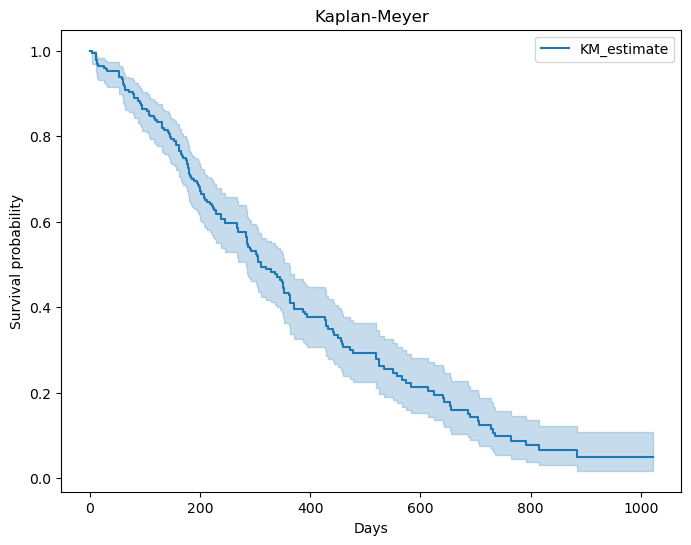

In [16]:
# Plotting survival
import matplotlib.pyplot as plt
model.plot(figsize = (8,6))
plt.title("Kaplan-Meyer")
plt.xlabel("Days")
plt.ylabel("Survival probability")

Text(0, 0.5, 'Death likelihood')

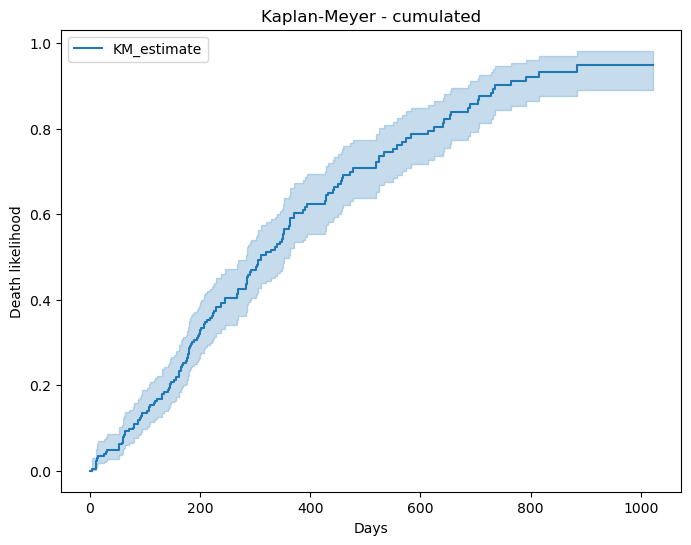

In [17]:
# Plotting cumulated deaths
model.plot_cumulative_density(figsize = (8,6))
plt.title("Kaplan-Meyer - cumulated")
plt.xlabel("Days")
plt.ylabel("Death likelihood")

In [18]:
# Subsetting between male and female
Male = dataset.query("sex == 1")
Female = dataset.query("sex == 2")

In [20]:
# Kaplan Meier Estimator
model_m = KaplanMeierFitter()
model_m.fit(durations = Male["time"], event_observed = Male["status"])
model_f = KaplanMeierFitter()
model_f.fit(durations = Female["time"], event_observed = Female["status"])

<lifelines.KaplanMeierFitter:"KM_estimate", fitted with 90 total observations, 37 right-censored observations>

Text(0, 0.5, 'Survival probability')

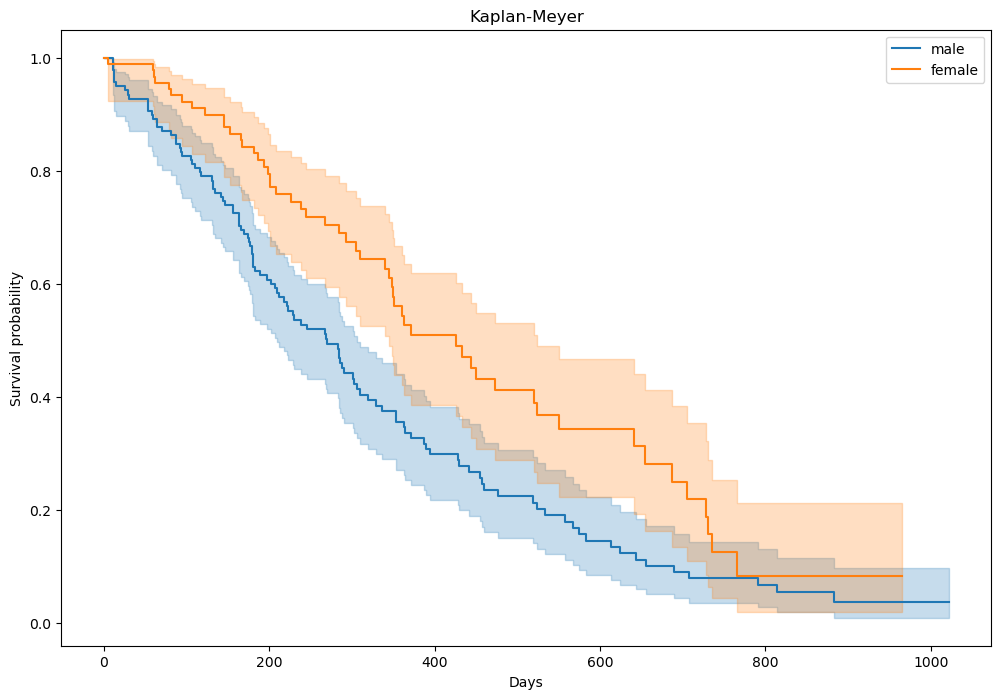

In [23]:
# Plotting
model_m.plot(figsize = (12,8), label="male")
model_f.plot(label="female")
plt.title("Kaplan-Meyer")
plt.xlabel("Days")
plt.ylabel("Survival probability")

In [24]:
# Log rank test
from lifelines.statistics import logrank_test
logrank = logrank_test(durations_A = Male["time"],
                       durations_B = Female["time"],
                       event_observed_A = Male["status"],
                       event_observed_B = Female["status"])
print(logrank)

<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic      p  -log2(p)
          10.33 <0.005      9.57


In [25]:
# Import the dataset
dataset = pd.read_csv("data/solder.csv")
dataset.head()

,Opening,Solder,Mask,PadType,Panel,skips
0,L,Thick,A1.5,W4,1,0
1,L,Thick,A1.5,W4,2,0
2,L,Thick,A1.5,W4,3,0
3,L,Thick,A1.5,D4,1,0
4,L,Thick,A1.5,D4,2,0


In [27]:
# Transform survival variable
import numpy as np
dataset["Solder"] = np.where(dataset["Solder"] == "Thin", 1, 0)

In [28]:
model = KaplanMeierFitter()
model.fit(durations=dataset["skips"], event_observed=dataset["Solder"])

<lifelines.KaplanMeierFitter:"KM_estimate", fitted with 900 total observations, 450 right-censored observations>

Text(0.5, 0, 'Skips')

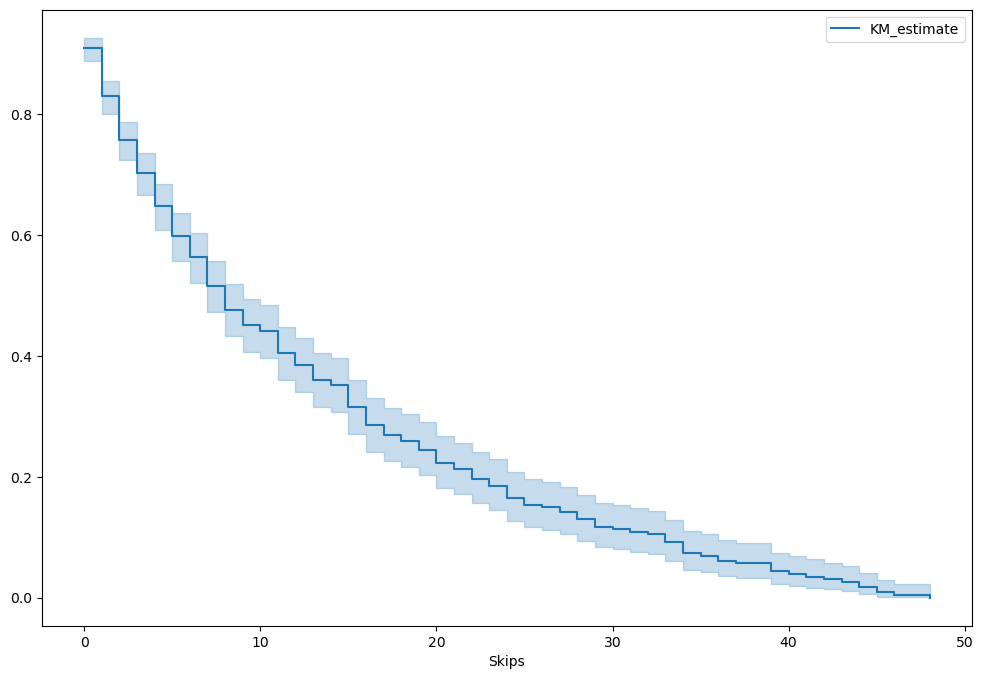

In [29]:
model.plot(figsize=(12, 8))
plt.xlabel("Skips")

In [30]:
dataset.Panel.unique()

array([1, 2, 3])

In [31]:
# Log rank test
from lifelines.statistics import multivariate_logrank_test

logrank = multivariate_logrank_test(
    dataset["skips"], dataset["Panel"], dataset["Solder"]
)
print(logrank)

<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 2
         test_name = multivariate_logrank_test

---
 test_statistic    p  -log2(p)
           6.84 0.03      4.93
